# 05. Personalization Strategy

This notebook translates the cart-to-purchase model predictions into practical, probability-based personalization strategies. It defines customer-action segments while distinguishing low-cost interventions from costly incentives.

In [1]:
# Purpose: Load the final modeling dataset and trained CatBoost model for personalization strategy analysis.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

current_path = Path.cwd().resolve()

project_root = next(
    (
        candidate
        for candidate in [current_path, *current_path.parents]
        if (candidate / "data").exists()
    ),
    current_path
)

processed_data_dir = project_root / "data" / "processed"
figures_dir = project_root / "outputs" / "figures"
tables_dir = project_root / "outputs" / "tables"
models_dir = project_root / "outputs" / "models"

modeling_data_path = processed_data_dir / "cart_purchase_modeling_dataset.csv"
model_path = models_dir / "final_catboost_cart_purchase_model.cbm"

cart_modeling_df = pd.read_csv(modeling_data_path, parse_dates=["cart_time"])

final_catboost_model = CatBoostClassifier()
final_catboost_model.load_model(model_path)

target_column = "purchased_within_14_days"
identifier_columns = ["visitorid", "itemid", "cart_time", target_column]

model_feature_columns = [
    column
    for column in cart_modeling_df.columns
    if column not in identifier_columns
]

print(f"Project root: {project_root}")
print(f"Modeling dataset shape: {cart_modeling_df.shape}")
print(f"Number of model features: {len(model_feature_columns)}")
print(f"Loaded model: {model_path.name}")
print(f"Observed purchase rate: {cart_modeling_df[target_column].mean():.2%}")

Project root: F:\ecommerce-recommender-xai
Modeling dataset shape: (56385, 27)
Number of model features: 23
Loaded model: final_catboost_cart_purchase_model.cbm
Observed purchase rate: 30.70%


In [2]:
# Purpose: Generate purchase probabilities for the temporally held-out carts used to evaluate personalization strategies.

time_cutoff = cart_modeling_df["cart_time"].quantile(0.80)

strategy_df = (
    cart_modeling_df.loc[
        cart_modeling_df["cart_time"] > time_cutoff
    ]
    .copy()
    .sort_values("cart_time")
    .reset_index(drop=True)
)

X_strategy = strategy_df[model_feature_columns]

strategy_df["predicted_purchase_probability"] = (
    final_catboost_model.predict_proba(X_strategy)[:, 1]
)

selected_threshold = 0.25
strategy_df["predicted_purchase_at_selected_threshold"] = (
    strategy_df["predicted_purchase_probability"] >= selected_threshold
).astype(int)

print(f"Temporal strategy dataset shape: {strategy_df.shape}")
print(f"Strategy period: {strategy_df['cart_time'].min()} to {strategy_df['cart_time'].max()}")
print(f"Observed purchase rate: {strategy_df[target_column].mean():.2%}")
print(
    "Average predicted purchase probability: "
    f"{strategy_df['predicted_purchase_probability'].mean():.2%}"
)
print(
    "Carts predicted as likely purchases at threshold 0.25: "
    f"{strategy_df['predicted_purchase_at_selected_threshold'].mean():.2%}"
)

display(
    strategy_df[
        [
            "visitorid",
            "itemid",
            "cart_time",
            target_column,
            "predicted_purchase_probability",
            "predicted_purchase_at_selected_threshold"
        ]
    ].head()
)

Temporal strategy dataset shape: (11277, 29)
Strategy period: 2015-08-07 21:00:50.702000 to 2015-09-04 02:50:59.633000
Observed purchase rate: 29.27%
Average predicted purchase probability: 29.68%
Carts predicted as likely purchases at threshold 0.25: 46.63%


,visitorid,itemid,cart_time,purchased_within_14_days,predicted_purchase_probability,predicted_purchase_at_selected_threshold
0,352300,248037,2015-08-07 21:00:50.702,0,0.101843,0
1,352300,260735,2015-08-07 21:01:44.877,0,0.104914,0
2,1369853,23055,2015-08-07 21:03:14.606,0,0.310284,1
3,615132,136674,2015-08-07 21:04:13.316,0,0.735253,1
4,352300,202580,2015-08-07 21:05:11.699,0,0.101811,0


In [3]:
# Purpose: Segment carts by predicted purchase probability and summarize their observed outcomes.

segment_bins = [-0.001, 0.10, 0.25, 0.40, 0.70, 1.00]

segment_labels = [
    "Very low probability (<10%)",
    "Low probability (10% to <25%)",
    "Moderate probability (25% to <40%)",
    "High probability (40% to <70%)",
    "Very high probability (>=70%)"
]

strategy_df["purchase_probability_segment"] = pd.cut(
    strategy_df["predicted_purchase_probability"],
    bins=segment_bins,
    labels=segment_labels,
    include_lowest=True,
    right=False
)

segment_summary = (
    strategy_df.groupby("purchase_probability_segment", observed=False)
    .agg(
        cart_count=("visitorid", "size"),
        percentage_of_carts=("visitorid", lambda values: len(values) / len(strategy_df) * 100),
        average_predicted_probability=("predicted_purchase_probability", "mean"),
        observed_purchase_rate=(target_column, "mean"),
        observed_purchases=(target_column, "sum")
    )
    .reset_index()
)

segment_summary["percentage_of_carts"] = segment_summary["percentage_of_carts"].round(2)
segment_summary["average_predicted_probability"] = (
    segment_summary["average_predicted_probability"] * 100
).round(2)
segment_summary["observed_purchase_rate"] = (
    segment_summary["observed_purchase_rate"] * 100
).round(2)

segment_summary_path = tables_dir / "10_personalization_probability_segments.csv"
segment_summary.to_csv(segment_summary_path, index=False)

display(segment_summary)

print(f"Saved probability-segment summary to: {segment_summary_path}")

,purchase_probability_segment,cart_count,percentage_of_carts,average_predicted_probability,observed_purchase_rate,observed_purchases
0,Very low probability (<10%),1090,9.67,8.03,5.96,65
1,Low probability (10% to <25%),4929,43.71,17.36,17.24,850
2,Moderate probability (25% to <40%),2785,24.70,31.53,31.17,868
3,High probability (40% to <70%),1483,13.15,50.09,49.76,738
4,Very high probability (>=70%),990,8.78,79.10,78.79,780


Saved probability-segment summary to: F:\ecommerce-recommender-xai\outputs\tables\10_personalization_probability_segments.csv


In [4]:
# Purpose: Translate probability segments into cost-aware and non-causal personalization actions.

personalization_actions = pd.DataFrame({
    "purchase_probability_segment": segment_labels,
    "recommended_action": [
        "Avoid immediate repeated messaging; show relevant alternatives later.",
        "Use low-cost product recommendations or a delayed reminder.",
        "Use personalized reassurance, related products, and test a small incentive through A/B testing.",
        "Send a timely reminder and reduce checkout friction; avoid broad discounts.",
        "Prioritize seamless checkout, stock visibility, and service quality; do not offer a default discount."
    ],
    "intervention_cost": [
        "Very low",
        "Low",
        "Low to moderate",
        "Low",
        "Very low"
    ],
    "business_objective": [
        "Avoid wasting contact capacity on unlikely near-term purchases.",
        "Increase relevance without spending a financial incentive.",
        "Support conversion while experimentally identifying customers responsive to incentives.",
        "Prevent abandonment among carts already likely to convert.",
        "Protect margin by allowing naturally likely purchases to complete."
    ]
})

personalization_action_plan = segment_summary.merge(
    personalization_actions,
    on="purchase_probability_segment",
    how="left"
)

personalization_action_plan_path = (
    tables_dir / "12_personalization_action_plan.csv"
)
personalization_action_plan.to_csv(
    personalization_action_plan_path,
    index=False
)

display(personalization_action_plan)

print(f"Saved personalization action plan to: {personalization_action_plan_path}")

,purchase_probability_segment,cart_count,percentage_of_carts,average_predicted_probability,observed_purchase_rate,observed_purchases,recommended_action,intervention_cost,business_objective
0,Very low probability (<10%),1090,9.67,8.03,5.96,65,Avoid immediate repeated messaging; show relev...,Very low,Avoid wasting contact capacity on unlikely nea...
1,Low probability (10% to <25%),4929,43.71,17.36,17.24,850,Use low-cost product recommendations or a dela...,Low,Increase relevance without spending a financia...
2,Moderate probability (25% to <40%),2785,24.70,31.53,31.17,868,"Use personalized reassurance, related products...",Low to moderate,Support conversion while experimentally identi...
3,High probability (40% to <70%),1483,13.15,50.09,49.76,738,Send a timely reminder and reduce checkout fri...,Low,Prevent abandonment among carts already likely...
4,Very high probability (>=70%),990,8.78,79.10,78.79,780,"Prioritize seamless checkout, stock visibility...",Very low,Protect margin by allowing naturally likely pu...


Saved personalization action plan to: F:\ecommerce-recommender-xai\outputs\tables\12_personalization_action_plan.csv


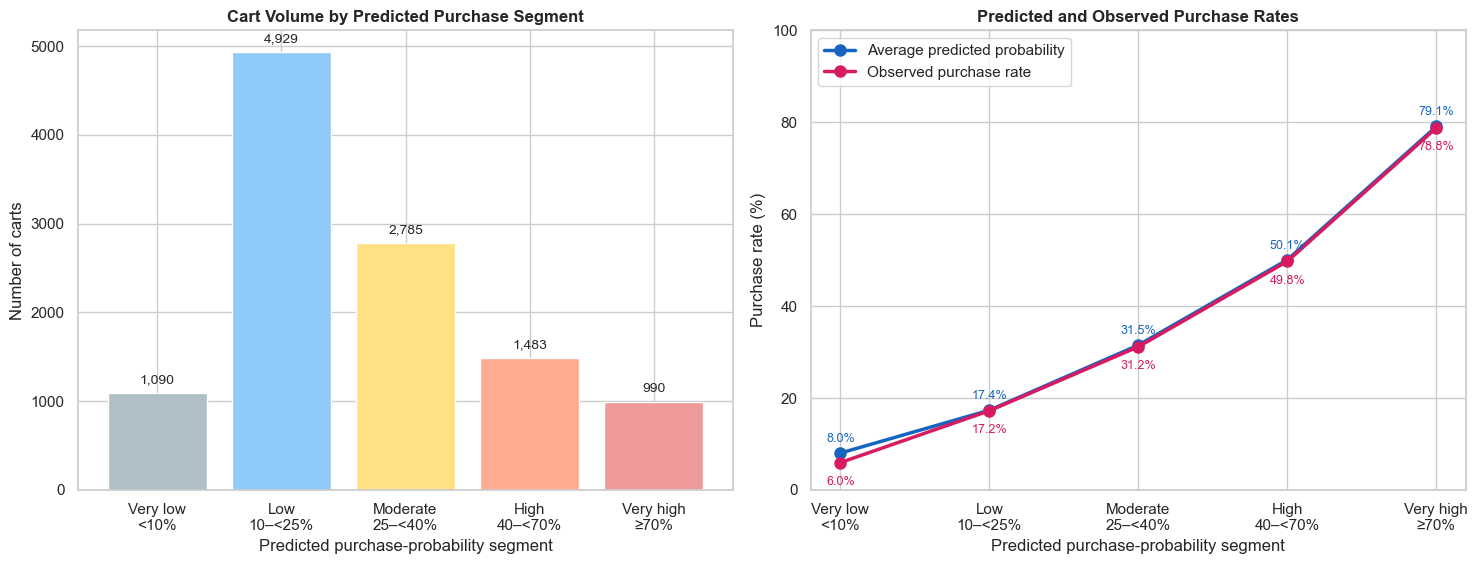

Saved personalization segment figure to: F:\ecommerce-recommender-xai\outputs\figures\15_personalization_probability_segments.png


In [5]:
# Purpose: Create and save a publication-ready chart of cart volumes and purchase-rate calibration across personalization segments.

segment_plot_df = personalization_action_plan.copy()

segment_plot_df["short_segment_label"] = [
    "Very low\n<10%",
    "Low\n10–<25%",
    "Moderate\n25–<40%",
    "High\n40–<70%",
    "Very high\n≥70%"
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

bar_colors = ["#B0BEC5", "#90CAF9", "#FFE082", "#FFAB91", "#EF9A9A"]

bars = axes[0].bar(
    segment_plot_df["short_segment_label"],
    segment_plot_df["cart_count"],
    color=bar_colors,
    edgecolor="white"
)

axes[0].set_title("Cart Volume by Predicted Purchase Segment", fontweight="bold")
axes[0].set_xlabel("Predicted purchase-probability segment")
axes[0].set_ylabel("Number of carts")

for bar, count in zip(bars, segment_plot_df["cart_count"]):
    axes[0].annotate(
        f"{count:,}",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10
    )

axes[1].plot(
    segment_plot_df["short_segment_label"],
    segment_plot_df["average_predicted_probability"],
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="#1565C0",
    label="Average predicted probability"
)

axes[1].plot(
    segment_plot_df["short_segment_label"],
    segment_plot_df["observed_purchase_rate"],
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="#D81B60",
    label="Observed purchase rate"
)

axes[1].set_title("Predicted and Observed Purchase Rates", fontweight="bold")
axes[1].set_xlabel("Predicted purchase-probability segment")
axes[1].set_ylabel("Purchase rate (%)")
axes[1].set_ylim(0, 100)
axes[1].legend(loc="upper left")

for x_position, predicted_rate, observed_rate in zip(
    range(len(segment_plot_df)),
    segment_plot_df["average_predicted_probability"],
    segment_plot_df["observed_purchase_rate"]
):
    axes[1].annotate(
        f"{predicted_rate:.1f}%",
        (x_position, predicted_rate),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        color="#1565C0",
        fontsize=9
    )
    axes[1].annotate(
        f"{observed_rate:.1f}%",
        (x_position, observed_rate),
        xytext=(0, -16),
        textcoords="offset points",
        ha="center",
        color="#D81B60",
        fontsize=9
    )

plt.tight_layout()

personalization_figure_path = (
    figures_dir / "15_personalization_probability_segments.png"
)
plt.savefig(personalization_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved personalization segment figure to: {personalization_figure_path}")

## Personalization Strategy Summary

The temporal test set was divided into five probability segments using the CatBoost-predicted probability of purchasing a carted item within 14 days. The observed purchase rate increased consistently from 5.96% in the very-low-probability segment to 78.79% in the very-high-probability segment.

The close agreement between average predicted probability and observed purchase rate across all segments indicates that the model is well calibrated for probability-based segmentation. This supports using the predictions to route carts toward different types of actions.

Importantly, purchase propensity is not the same as responsiveness to an intervention. Therefore, customers with a very high predicted purchase probability should not automatically receive discounts, because they may purchase naturally. Financial incentives should instead be tested experimentally, particularly for the moderate-probability segment.

### Saved personalization outputs

- `10_personalization_probability_segments.csv`: probability-segment performance summary
- `12_personalization_action_plan.csv`: cost-aware recommended actions by segment
- `15_personalization_probability_segments.png`: cart-volume and calibration figure